In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from src.data.ingestion import load_csv
from src.data.validation import validate
from src.data.transformation import transform
from src.models.train import train

In [60]:
df = load_csv("data/raw/Telco_Customer_Churn.csv")
validate(df)
df_transformed = transform(df)

Data loaded: 7043 rows, 21 columns
Transformation complete. Final shape: (7043, 31)


In [62]:
print(df_transformed.shape)
print(df_transformed.dtypes)

(7043, 31)
gender                                     int64
seniorcitizen                              int64
partner                                    int64
dependents                                 int64
tenure                                     int64
phoneservice                               int64
paperlessbilling                           int64
monthlycharges                           float64
totalcharges                             float64
churn                                      int64
multiplelines_no phone service              bool
multiplelines_yes                           bool
internetservice_fiber optic                 bool
internetservice_no                          bool
onlinesecurity_no internet service          bool
onlinesecurity_yes                          bool
onlinebackup_no internet service            bool
onlinebackup_yes                            bool
deviceprotection_no internet service        bool
deviceprotection_yes                        bool
techsuppo

In [65]:
from src.data.ingestion import load_csv
from src.data.validation import validate
from src.data.transformation import transform

# check exact column names after encoding
for col in df_transformed.columns:
    print(col)

gender
seniorcitizen
partner
dependents
tenure
phoneservice
paperlessbilling
monthlycharges
totalcharges
churn
multiplelines_no phone service
multiplelines_yes
internetservice_fiber optic
internetservice_no
onlinesecurity_no internet service
onlinesecurity_yes
onlinebackup_no internet service
onlinebackup_yes
deviceprotection_no internet service
deviceprotection_yes
techsupport_no internet service
techsupport_yes
streamingtv_no internet service
streamingtv_yes
streamingmovies_no internet service
streamingmovies_yes
contract_one year
contract_two year
paymentmethod_credit card (automatic)
paymentmethod_electronic check
paymentmethod_mailed check


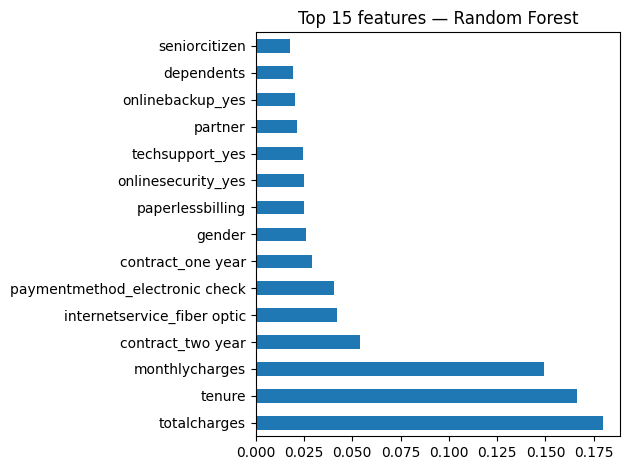

In [66]:
_, _, _, X_train, y_train, _, _, _, _, _, _ = train(df_transformed)

rf = joblib.load("models/random_forest.pkl")
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15).plot(kind="barh")
plt.title("Top 15 features — Random Forest")
plt.tight_layout()
plt.show()